# Experiment 3 — Hard vs Soft (Gaussian) Matching

**Goal:** Compare nearest-neighbour (hard) ICP against Gaussian-weighted (soft) ICP with sigma annealing on the `clustered` cloud style.

1. Per-iteration convergence curves for a single run (residual, rotation error, translation error).
2. Convergence time and amount of steps

In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np

from icp import ICP, SigmaAnnealingCallback
from experiment_runner import fit_multi_seed
from matcher import NearestNeighborMatcher, GaussianMatcher
from visualization import ErrorMetricsVisualizer, TimeVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS    = 30
MAX_ITER   = 400
TOL        = 1e-3
EXP_KWARGS = dict(n=2000, noise_std=3.0, t_scale=8.0, style='clustered')

# Gaussian matcher / annealing hyperparameters
SIGMA_INIT  = 25.0
SIGMA_FINAL = 1.0
K_NEIGHBORS = 20

matcher = GaussianMatcher(sigma=SIGMA_INIT, k=K_NEIGHBORS)
annealer = SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
softICP = ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer], record_history=False)    # Soft ICP (Gaussian with annealing)
hardICP = ICP(matcher=NearestNeighborMatcher(), max_iter=MAX_ITER, tol=TOL, record_history=False)         # Hard ICP (nearest-neighbour)

## 1. Compare error metrics convergence

Both matchers run on the same experiment on several seeds. The per-iteration curves show how fast each one descends and whether they reach the correct solution.

In [2]:
results_hard = fit_multi_seed(hardICP, seeds=list(range(N_SEEDS)), experiment_kwargs=EXP_KWARGS)
results_soft = fit_multi_seed(softICP, seeds=list(range(N_SEEDS)), experiment_kwargs=EXP_KWARGS)

Solving 30 seeds: 100%|██████████| 30/30 [01:31<00:00,  3.03s/it]


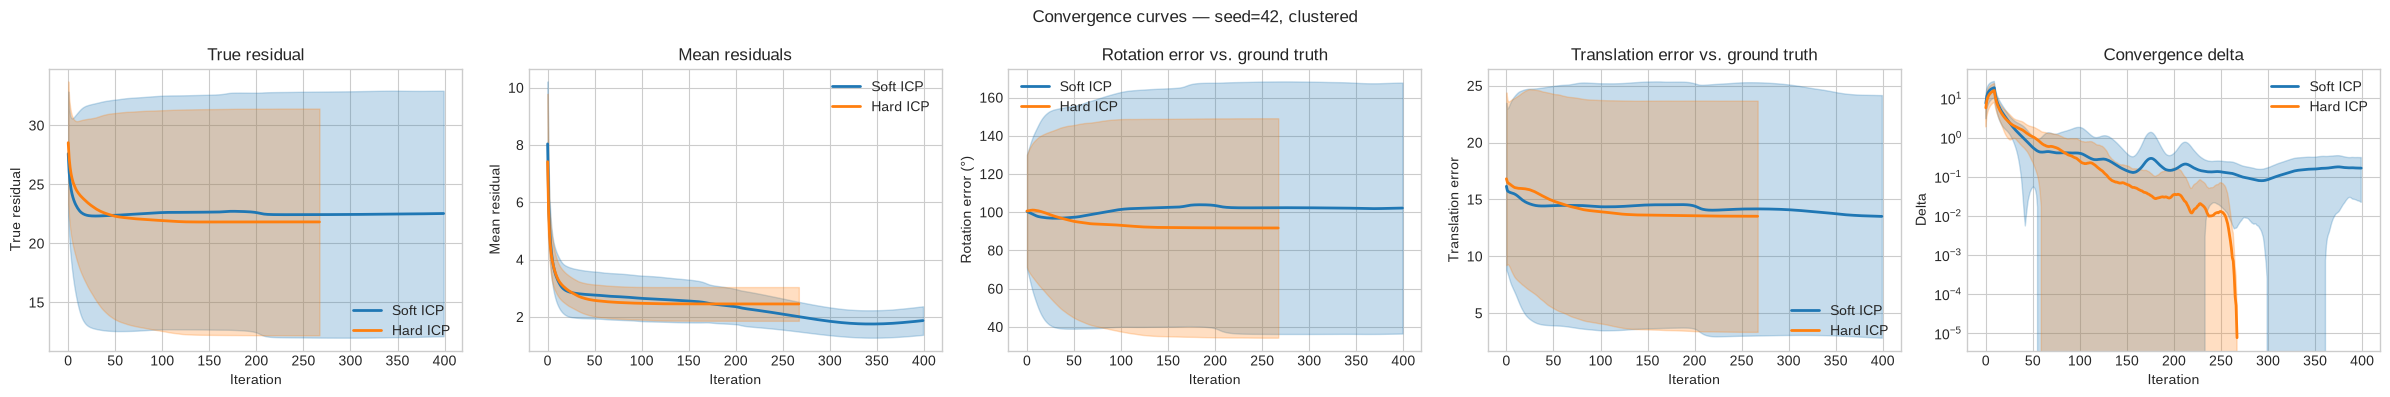

In [3]:
ErrorMetricsVisualizer.plot_convergence(
    results_per_method=[results_soft.results, results_hard.results],
    experiments_per_method=[results_soft.experiments, results_hard.experiments],
    method_labels=["Soft ICP", "Hard ICP"],
    x_label='Iteration',
)

plt.suptitle('Convergence curves — seed=42, clustered')
plt.tight_layout()
plt.savefig('../results/3_hard_vs_soft_matching_error_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Runtime distribution across seeds

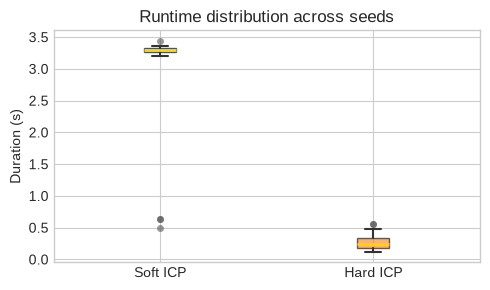

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))
TimeVisualizer.plot_duration_distribution(
    ax,
    durations_per_method=[results_soft.durations_s, results_hard.durations_s],
    method_labels=["Soft ICP", "Hard ICP"],
)
plt.tight_layout()
plt.savefig('../results/3_hard_vs_soft_matching_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()